# Bolum 6: Hugging Face Transformers ile Spam Tespiti

Bu notebook, Hugging Face Transformers kutuphanesini kullanarak GPT-2 modelini spam tespiti icin fine-tune eder.

## Kitaptaki Bolum 6.5 yaklasimi:
1. GPT-2 agirliklarini yukle
2. Tum parametreleri dondur (freeze)
3. out_head degistir (768 -> 2)
4. Son transformer blogunu ac (h[-1])
5. Final LayerNorm ac (ln_f)
6. out_head ac

## 1. Kutuphaneler

In [37]:
import torch
import pandas as pd
import numpy as np
from transformers import GPT2Model, GPT2Tokenizer
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from tqdm import tqdm
import os

# GPU kontrolu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanilan cihaz: {device}")

Kullanilan cihaz: cuda

## 2. Veri Yukleme

In [38]:
data_dir = "./"
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "validation.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(f"Egitim: {len(train_df)}, Dogrulama: {len(val_df)}, Test: {len(test_df)}")

Egitim: 1045, Dogrulama: 149, Test: 300

## 3. Dataset

In [39]:
class SpamDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df['Text'].tolist()
        self.labels = df['Label'].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

## 4. GPT-2 Yukleme

In [40]:
print("GPT-2 yukleniyor...")
tokenizer = GPT2Tokenizer.from_pretrained("openai-community/gpt2")
tokenizer.pad_token = tokenizer.eos_token

gpt2 = GPT2Model.from_pretrained("openai-community/gpt2")
print(f"Katman: {gpt2.config.n_layer}, Embed: {gpt2.config.n_embd}")

GPT-2 yukleniyor...

Katman: 12, Embed: 768

## 5. Model: Kitaptaki gibi out_head ekleme

Kitaptaki kod:
```python
model.out_head = torch.nn.Linear(in_features=768, out_features=2)
```

HF GPT2Model'de aynisi:

In [41]:
# Kitaptaki gibi: out_head ekle (768 -> 2)
gpt2.out_head = nn.Linear(768, 2)
model = gpt2
model.to(device)

print(f"Model hazir!")
print(f"Toplam parametre: {sum(p.numel() for p in model.parameters()):,}")

Model hazir!

Toplam parametre: 124,441,346

## 6. Fine-tuning - Kitaptaki Bole 6.5

In [42]:
# Adim 1: Tum parametreleri dondur
for param in model.parameters():
    param.requires_grad = False

print(f"Donduruldu: {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")

Donduruldu: 124,441,346

In [43]:
# Adim 2: Belirli katmanlari ac (kitaptaki gibi)

# Son transformer blogunu ac (h[-1])
for param in model.h[-1].parameters():
    param.requires_grad = True

# Final LayerNorm ac (ln_f)
for param in model.ln_f.parameters():
    param.requires_grad = True

# out_head ac
for param in model.out_head.parameters():
    param.requires_grad = True

print(f"Egitilebilir: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Egitilebilir: 7,090,946

## 7. DataLoader

In [44]:
train_dataset = SpamDataset(train_df, tokenizer, max_length=128)
val_dataset = SpamDataset(val_df, tokenizer, max_length=128)
test_dataset = SpamDataset(test_df, tokenizer, max_length=128)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print(f"Egitim batch: {len(train_loader)}")

Egitim batch: 66

## 8. Egitim Dongusu

In [45]:
from torch.optim import AdamW

num_epochs = 5
learning_rate = 2e-5

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

In [46]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in tqdm(loader, desc="Egitim"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Forward: son token uzerinden
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_token = outputs.last_hidden_state[:, -1, :]  # Son token
        logits = model.out_head(last_token)
        
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Degerlendirme"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            last_token = outputs.last_hidden_state[:, -1, :]
            logits = model.out_head(last_token)
            
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / len(loader), correct / total

In [47]:
best_val_acc = 0

# Eğitim geçmişini kaydet
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    
    # Geçmişe ekle
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Train: {train_loss:.4f} | {train_acc*100:.2f}%")
    print(f"Val: {val_loss:.4f} | {val_acc*100:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "spam_classifier.pth")
        print(f"En iyi model kaydedildi!")

print(f"\nEn iyi val acc: {best_val_acc*100:.2f}%")

Epoch 1/5

Degerlendirme: 100%|██████████| 10/10 [00:00<00:00, 17.59it/s]


Train: 0.8545 | 51.96%

Val: 0.6067 | 87.92%

En iyi model kaydedildi!

...

Epoch 5/5

Degerlendirme: 100%|██████████| 10/10 [00:00<00:00, 17.80it/s]


Train: 0.1899 | 95.02%

Val: 0.0864 | 97.32%

En iyi val acc: 97.99%

## 8. Loss ve Accuracy Grafikleri

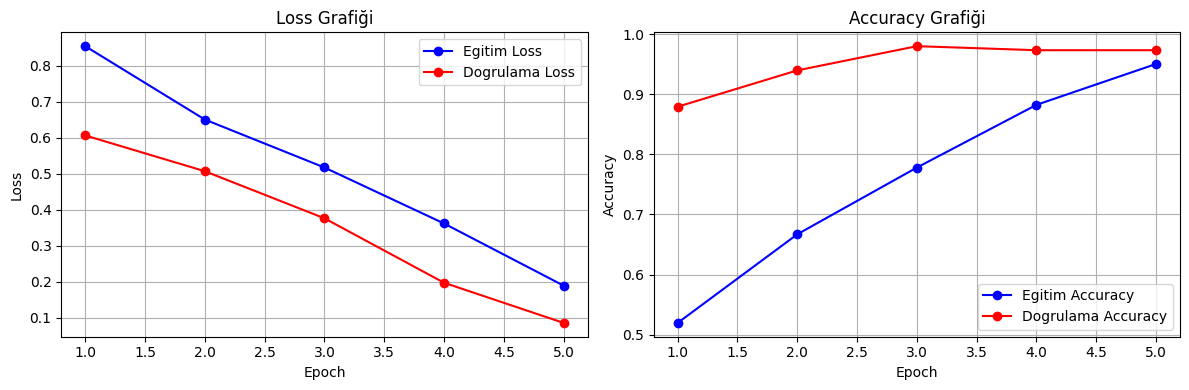

Grafikler kaydedildi: training_plots.png

In [48]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# Loss grafigi
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'b-o', label='Egitim Loss')
plt.plot(epochs, history['val_loss'], 'r-o', label='Dogrulama Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Grafiği')
plt.legend()
plt.grid(True)

# Accuracy grafigi
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 'b-o', label='Egitim Accuracy')
plt.plot(epochs, history['val_acc'], 'r-o', label='Dogrulama Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Grafiği')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Grafikler kaydedildi: training_plots.png")

## 9. Test Degerlendirmesi

In [49]:
model.load_state_dict(torch.load("spam_classifier.pth"))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Test: {test_acc*100:.2f}%")

Degerlendirme: 100%|██████████| 19/19 [00:01<00:00, 15.40it/s]


Test: 92.67%

## 10. Hugging Face'e Yukleme

In [50]:
# HF formatinda kaydet
output_dir = "./hf_spam_model"
os.makedirs(output_dir, exist_ok=True)

# Model ve tokenizer kaydet
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print(f"Model {output_dir} klasorune kaydedildi!")

Model ./hf_spam_model klasorune kaydedildi!

In [53]:
# Hugging Face Hub'a yukle
from huggingface_hub import HfApi, login

# Token ile giris
# login(token="HF_TOKEN")  # Token'inizi girin

# Model adi
repo_id = "Mustafaege/spam-detector-gpt2-hf"

# Yukle
#api = HfApi()
#api.create_repo(repo_id=repo_id, exist_ok=True)
#api.upload_folder(folder_path=output_dir, repo_id=repo_id, repo_type="model")

print(f"URL: https://huggingface.co/{repo_id}")

URL: https://huggingface.co/Mustafaege/spam-detector-gpt2-hf

## Ozet

Kitaptaki Bole 6.5 ile ayni:
- out_head degistirildi (768 -> 2)
- h[-1] acildi
- ln_f acildi
- out_head acildi
- Son token uzerinden siniflandirma

## 11. Hugging Face Kullanim Ornekleri

### Pipeline ile Kullanim

In [ ]:
from transformers import pipeline

# Modeli pipeline ile yukle
classifier = pipeline("text-classification", model="Mustafaege/spam-detector-gpt2-hf")

# Spam mesaj testi
result = classifier("Congratulations! You've won a free prize! Click here now!")
print(result)
# Cıktı: [{'label': 'LABEL_1', 'score': 0.98}]

# Normal mesaj testi
result = classifier("Hey, are we still meeting tomorrow?")
print(result)
# Cıktı: [{'label': 'LABEL_0', 'score': 0.95}]

### Manuel Kullanim

In [ ]:
from transformers import GPT2Model, GPT2Tokenizer
import torch
import torch.nn as nn

# Model ve tokenizer yukle
model_name = "Mustafaege/spam-detector-gpt2-hf"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2Model.from_pretrained(model_name)

# out_head ekle (eger yoksa)
model.out_head = nn.Linear(768, 2)

# Mesaj hazirla
text = "Free prize! Click here now!"
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

# Son token hidden state al
outputs = model(**inputs)
last_token_hidden = outputs.last_hidden_state[:, -1, :]

# Tahmin yap
logits = model.out_head(last_token_hidden)
prediction = torch.argmax(logits, dim=-1)

print("SPAM" if prediction.item() == 1 else "NOT SPAM")

### Etiket Bilgileri

- `LABEL_0`: Not Spam (Normal mesaj)
- `LABEL_1`: Spam